<a href="https://colab.research.google.com/github/Arij0106/Predective-Modelling-and-Natural-Language-Processing/blob/main/Level3_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1:predective modelling (classification)

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [5]:
url = "https://raw.githubusercontent.com/Arij0106/Predective-Modelling-and-Natural-Language-Processing/refs/heads/main/sentiment.csv"
df = pd.read_csv(url)

In [6]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    object 
 3   Sentiment     732 non-null    object 
 4   Timestamp     732 non-null    object 
 5   User          732 non-null    object 
 6   Platform      732 non-null    object 
 7   Hashtags      732 non-null    object 
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    object 
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 85.9+ KB


,0
Unnamed: 0.1,0
Unnamed: 0,0
Text,0
Sentiment,0
Timestamp,0
User,0
Platform,0
Hashtags,0
Retweets,0
Likes,0


In [7]:
df.drop('Unnamed: 0', axis=1, inplace=True)

In [8]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Sentiment'] = le.fit_transform(df['Sentiment'])
print(dict(zip(le.classes_, le.transform(le.classes_))))

{' Acceptance   ': np.int64(0), ' Acceptance      ': np.int64(1), ' Accomplishment ': np.int64(2), ' Admiration ': np.int64(3), ' Admiration   ': np.int64(4), ' Admiration    ': np.int64(5), ' Adoration    ': np.int64(6), ' Adrenaline     ': np.int64(7), ' Adventure ': np.int64(8), ' Affection    ': np.int64(9), ' Amazement ': np.int64(10), ' Ambivalence ': np.int64(11), ' Ambivalence     ': np.int64(12), ' Amusement    ': np.int64(13), ' Amusement     ': np.int64(14), ' Anger        ': np.int64(15), ' Anticipation ': np.int64(16), ' Anticipation  ': np.int64(17), ' Anxiety   ': np.int64(18), ' Anxiety         ': np.int64(19), ' Appreciation  ': np.int64(20), ' Apprehensive ': np.int64(21), ' Arousal       ': np.int64(22), ' ArtisticBurst ': np.int64(23), ' Awe ': np.int64(24), ' Awe    ': np.int64(25), ' Awe          ': np.int64(26), ' Awe           ': np.int64(27), ' Bad ': np.int64(28), ' Betrayal ': np.int64(29), ' Betrayal      ': np.int64(30), ' Bitter       ': np.int64(31), ' Bi

In [9]:
X = df.drop('Sentiment', axis=1)
y = df['Sentiment']

In [10]:
X = X.drop(['Text', 'Timestamp', 'User', 'Hashtags'], axis=1, errors='ignore')

In [11]:
X = pd.get_dummies(X, drop_first=True)

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [15]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(y_test, y_pred, name):

    print(f"\n{name}")

    print("Accuracy :", accuracy_score(y_test, y_pred))

    print("Precision:", precision_score(
        y_test, y_pred, average='weighted'
    ))

    print("Recall   :", recall_score(
        y_test, y_pred, average='weighted'
    ))

    print("F1 Score :", f1_score(
        y_test, y_pred, average='weighted'
    ))

In [18]:
evaluate_model(y_test, y_pred_lr, "Logistic Regression")

evaluate_model(y_test, y_pred_dt, "Decision Tree")

evaluate_model(y_test, y_pred_rf, "Random Forest")


Logistic Regression
Accuracy : 0.1836734693877551
Precision: 0.1833298976156119
Recall   : 0.1836734693877551
F1 Score : 0.17344877344877344

Decision Tree
Accuracy : 0.2653061224489796
Precision: 0.3112244897959184
Recall   : 0.2653061224489796
F1 Score : 0.27214786347439407

Random Forest
Accuracy : 0.2789115646258503
Precision: 0.2689815853081159
Recall   : 0.2789115646258503
F1 Score : 0.2602968460111317


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [19]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)
grid.fit(X_train, y_train)
print(grid.best_params_)
best_rf = grid.best_estimator_

y_pred_best = best_rf.predict(X_test)

evaluate_model(y_test, y_pred_best, "Tuned Random Forest")


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

Tuned Random Forest
Accuracy : 0.2789115646258503
Precision: 0.27311180882609454
Recall   : 0.2789115646258503
F1 Score : 0.2624024501575522


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Task 3: Natural Language Processing (NLP) - Sentiment Analysis

In [20]:
import pandas as pd
import nltk
import matplotlib.pyplot as plt

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from textblob import TextBlob
from wordcloud import WordCloud
from collections import Counter

In [21]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [22]:
df['Text'] = df['Text'].astype(str)
df['Text'] = df['Text'].str.lower()

In [23]:
import nltk
nltk.download('punkt_tab')
df['Tokens'] = df['Text'].apply(word_tokenize)
df[['Text', 'Tokens']].head()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,Text,Tokens
0,enjoying a beautiful day at the park! ...,"[enjoying, a, beautiful, day, at, the, park, !]"
1,traffic was terrible this morning. ...,"[traffic, was, terrible, this, morning, .]"
2,just finished an amazing workout! 💪 ...,"[just, finished, an, amazing, workout, !, 💪]"
3,excited about the upcoming weekend getaway! ...,"[excited, about, the, upcoming, weekend, getaw..."
4,trying out a new recipe for dinner tonight. ...,"[trying, out, a, new, recipe, for, dinner, ton..."


In [24]:
stop_words = set(stopwords.words('english'))

df['Tokens'] = df['Tokens'].apply(
    lambda words: [word for word in words if word.isalpha() and word not in stop_words]
)

In [25]:
stemmer = PorterStemmer()

df['Stemmed'] = df['Tokens'].apply(
    lambda words: [stemmer.stem(word) for word in words]
)

In [26]:
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

In [27]:
df['Predicted_Sentiment'] = df['Text'].apply(get_sentiment)

df[['Text', 'Predicted_Sentiment']].head()

,Text,Predicted_Sentiment
0,enjoying a beautiful day at the park! ...,Positive
1,traffic was terrible this morning. ...,Negative
2,just finished an amazing workout! 💪 ...,Positive
3,excited about the upcoming weekend getaway! ...,Positive
4,trying out a new recipe for dinner tonight. ...,Positive


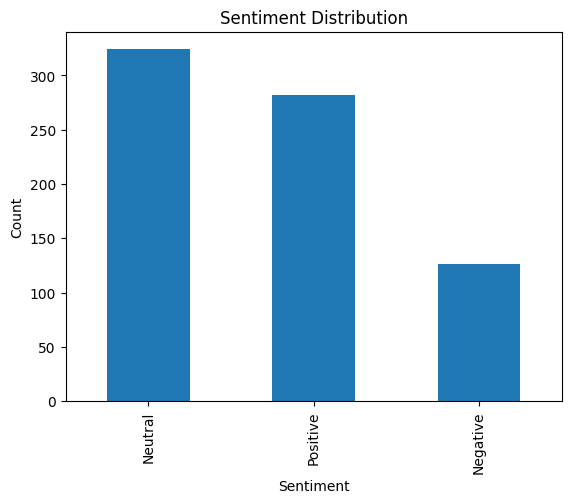

In [28]:
df['Predicted_Sentiment'].value_counts().plot(kind='bar')

plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')

plt.show()

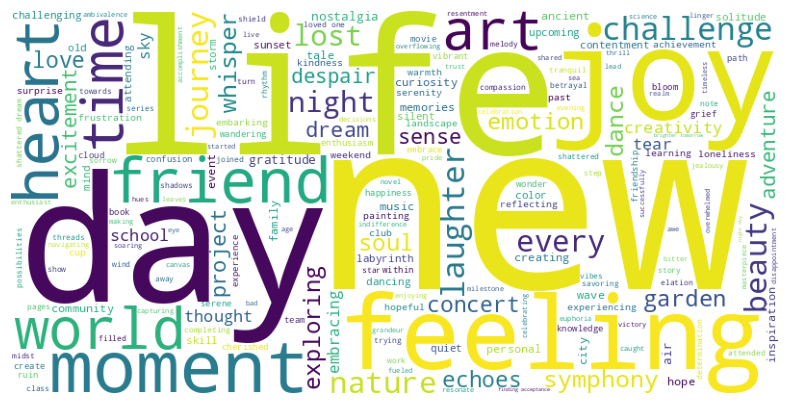

In [29]:
all_words = ' '.join(df['Text'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

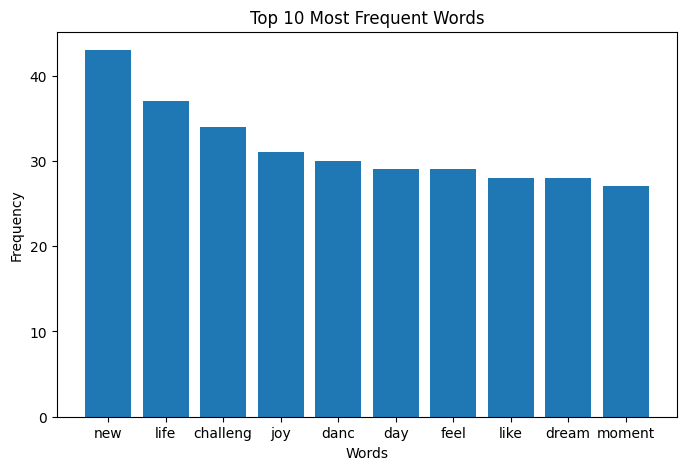

In [30]:
all_words_list = []

for words in df['Stemmed']:
    all_words_list.extend(words)

word_counts = Counter(all_words_list)

top_words = word_counts.most_common(10)

words = [word for word, count in top_words]
counts = [count for word, count in top_words]

plt.figure(figsize=(8,5))
plt.bar(words, counts)

plt.title('Top 10 Most Frequent Words')
plt.xlabel('Words')
plt.ylabel('Frequency')

plt.show()